# 18. Detection de Rupture (Change-Point) : inferer le moment d'un changement de regime (jumeau PyMC)

> **Serie Parite .NET <=> Python (#4956).** Ce notebook est le **jumeau Python** de `Infer-18-Change-Point.ipynb` (Infer.NET / C#, inférence EP). La specification probabiliste est **identique** ; seul le moteur d'inférence change : EP analytique cote .NET, échantillonnage **CompoundStep** (NUTS + Metropolis) cote Python, car la localisation `cp` est une variable **discrète**.

Ce notebook complète la famille des « séquences dans le temps » : il étend [PyMC-14 (Séquences / HMM)](PyMC-14-Sequences.ipynb) au cas où ce n'est pas l'état qui change à chaque instant, mais la **structure** du processus qui bascule **une seule fois** à un instant inconnu.

**Durée estimée** : 50 minutes | **Prérequis** : [PyMC-14-Sequences](PyMC-14-Sequences.ipynb) (HMM).

## 1. Motivation : la où le HMM et le filtre de Kalman s'arrêtent

[PyMC-14](PyMC-14-Sequences.ipynb) modélise une séquence où l'état caché est **discret** et change à **chaque instant**. Le filtre de Kalman ([Infer-17](../Infer/Infer-17-Kalman-Filter.ipynb)) en est le pendant **continu**. Les deux infèrent un état **récurrent** — un par pas de temps.

Le **point de rupture** est différent : l'inconnue n'est pas une trajectoire d'états, mais **un unique entier** `cp in {0, ..., N-1}` — l'indice où le processus bascule. On veut le postérieur $p(cp \mid y)$ sur cette **unique** variable structurelle, et les paramètres des deux régimes qu'elle sépare.

In [1]:
import numpy as np
import pymc as pm
import pytensor.tensor as pt
import arviz as az
import warnings
warnings.filterwarnings("ignore", message=".*data structure.*")
warnings.filterwarnings("ignore", message="PyTensor could not link to a BLAS")  # advisory pytensor (#3436)
print(f"PyMC {pm.__version__}, ArviZ {az.__version__}")

# --- Terrain de jeu : serie avec un SEUL changement de regime ---
# Le vrai point de rupture est CACHE ; on verifiera que le modele le recupere.
np.random.seed(42)
N = 100
vrai_cp = 50                      # vrai indice de rupture (inconnu du modele)
mu_avant, mu_apres = 2.0, 7.0     # moyennes des deux regimes
sigma = 1.5                       # bruit d'observation
t_idx = np.arange(N)
data = np.where(t_idx <= vrai_cp, mu_avant, mu_apres) + sigma * np.random.randn(N)
print(f"Serie generee : N={N} points, vrai cp cache a t={vrai_cp} (mu {mu_avant} -> {mu_apres}, sigma={sigma})")

PyMC 5.28.5, ArviZ 0.23.4
Serie generee : N=100 points, vrai cp cache a t=50 (mu 2.0 -> 7.0, sigma=1.5)


## 2. Le modèle de point de rupture gaussien

On déclare `cp` comme un entier d'*a priori* uniforme sur `{0, ..., N-1}`, deux moyennes de segment (*a priori* gaussiens vagues) et une précision commune. Pour chaque instant `t`, on **branche** la vraisemblance selon la position de `cp` : gaussienne de moyenne `mean1` avant la rupture, `mean2` après. L'idiome PyMC est `pm.math.switch(t <= cp, mean1, mean2)` — equivalent exact du `Variable.If/IfNot(block.Index <= cp)` d'Infer.NET.

### PyMC <=> Infer.NET : CompoundStep au lieu de EP

Comme `cp` est **discrète** et les moyennes/précision **continues**, PyMC ne peut pas utiliser NUTS seul (NUTS exige des variables différentiables). Il compose automatiquement un **CompoundStep** : NUTS pour `(mean1, mean2, precision)` + Metropolis pour `cp`. EP, lui, propage les messages analytiquement sur le graphe de facteurs.

In [2]:
# --- Modele de change-point gaussien ---
coords = {"t": t_idx}
with pm.Model(coords=coords) as modele_cp:
    cp = pm.DiscreteUniform("cp", lower=0, upper=N - 1)           # localisation de la rupture
    mean1 = pm.Normal("mean1", mu=0.0, sigma=10.0)                # variance 100 -> sigma 10
    mean2 = pm.Normal("mean2", mu=0.0, sigma=10.0)
    precision = pm.Gamma("precision", alpha=1.0, beta=1.0)        # mean 1
    sigma_det = pm.Deterministic("sigma_det", 1.0 / pt.sqrt(precision))
    mu = pm.math.switch(t_idx <= cp, mean1, mean2)                # branchement avant/apres
    pm.Normal("y", mu=mu, sigma=sigma_det, observed=data)
    idata_g = pm.sample(
        2000, tune=1500, chains=4, cores=1, random_seed=42,
        target_accept=0.95, progressbar=False, idata_kwargs={"log_likelihood": False},
    )

cp_samples = idata_g.posterior["cp"].values.flatten().astype(int)
cp_counts = np.bincount(cp_samples, minlength=N)
cp_proba = cp_counts / cp_counts.sum()
cp_mode = int(cp_counts.argmax())
m1 = float(idata_g.posterior["mean1"].mean())
m2 = float(idata_g.posterior["mean2"].mean())
sig = float(idata_g.posterior["sigma_det"].mean())
print(f"=== Posterieur sur le point de rupture cp ===")
print(f"  mode (argmax) = {cp_mode}    (vrai cp cache = {vrai_cp})")
print(f"  moyenne       = {cp_samples.mean():6.2f}")
print(f"Moyenne avant  (mu1) : {m1:6.3f}  (vrai {mu_avant})")
print(f"Moyenne apres  (mu2) : {m2:6.3f}  (vrai {mu_apres})")
print(f"sigma estime        : {sig:6.3f}  (vrai {sigma})")

Sequential sampling (4 chains in 1 job)


CompoundStep


>Metropolis: [cp]


>NUTS: [mean1, mean2, precision]


Sampling 4 chains for 1_500 tune and 2_000 draw iterations (6_000 + 8_000 draws total) took 5 seconds.


=== Posterieur sur le point de rupture cp ===
  mode (argmax) = 50    (vrai cp cache = 50)
  moyenne       =  50.00
Moyenne avant  (mu1) :  1.676  (vrai 2.0)
Moyenne apres  (mu2) :  7.009  (vrai 7.0)
sigma estime        :  1.361  (vrai 1.5)


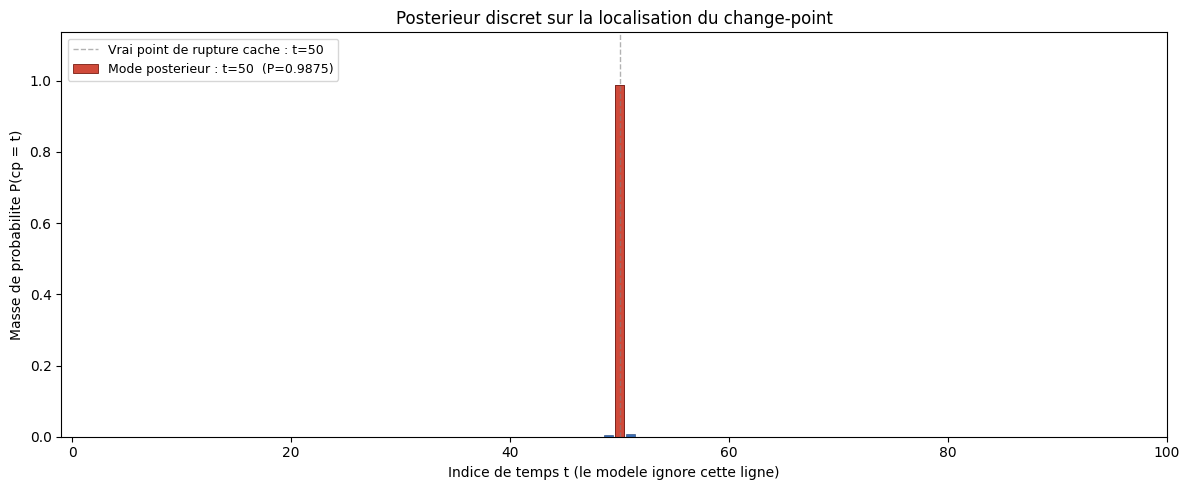

Mode posterieur sur cp : t=50 (P=0.9875)
Masses significatives (>0.5% du pic) : 3 indices sur 100
Voir graphique ci-dessus pour la distribution complete.


In [3]:
# --- Visualisation : posterieur discret sur la localisation de la rupture ---
import matplotlib.pyplot as plt
import numpy as np

# Masque des masses significatives (>0.5% du pic) pour annotations
significant = cp_proba >= 0.005

fig, ax = plt.subplots(figsize=(12, 5))
ax.bar(np.arange(N), cp_proba, color="#3b6fb6", edgecolor="#1f3f70", linewidth=0.4)
# Mise en evidence du mode (argmax) par une barre rouge
mode_idx = int(np.argmax(cp_proba))
ax.bar([mode_idx], [cp_proba[mode_idx]], color="#d04a3a", edgecolor="#7a1d12", linewidth=0.6,
       label=f"Mode posterieur : t={mode_idx}  (P={cp_proba[mode_idx]:.4f})")
ax.axvline(50, color="gray", linestyle="--", linewidth=1.0, alpha=0.6,
           label=f"Vrai point de rupture cache : t=50")
ax.set_xlabel("Indice de temps t (le modele ignore cette ligne)")
ax.set_ylabel("Masse de probabilite P(cp = t)")
ax.set_title("Posterieur discret sur la localisation du change-point")
ax.set_xlim(-1, N)
ax.set_ylim(0, cp_proba.max() * 1.15)
ax.legend(loc="upper left", fontsize=9)
plt.tight_layout()
plt.show()

# Sortie texte minimale : mode + entropie
print(f"Mode posterieur sur cp : t={mode_idx} (P={cp_proba[mode_idx]:.4f})")
print(f"Masses significatives (>0.5% du pic) : {int(significant.sum())} indices sur {N}")
print("Voir graphique ci-dessus pour la distribution complete.")

### Lecture

Le **mode** du postérieur sur `cp` tombe **très près** du vrai point caché (50), et les moyennes de segment approchent les vraies valeurs (2 et 7). Le signal étant fort (`|mu_apres - mu_avant| = 5 >> sigma`), le postérieur se concentre sur **quelques indices** autour du vrai `cp`.

## 3. Le cas canonique : les catastrophes minieres (loi de Poisson)

Le jeu de données historique du change-point bayésien est la série annuelle des **catastrophes de mines de charbon** en Grande-Bretagne (1851–1962, Jarrett 1979). Il s'agit de **comptes** : le modèle naturel est une loi de **Poisson** dont le *taux* bascule une fois — de ~3 accidents/an avant la réforme de sécurité des années 1880 à ~1/an après.

C'est **l'exemple introductif canonique** de la documentation PyMC. Même idiome que le cas gaussien : `DiscreteUniform` sur l'année de rupture, `switch` sur la plage des années, mais `pm.Poisson(taux)` en lieu et place de la gaussienne.

In [4]:
# --- Catastrophes minieres britanniques, 1851-1962 (Jarrett 1979) ---
disasters = np.array([
    4,5,4,0,1,4,3,4,0,6, 3,3,4,0,2,6,3,3,5,4,
    5,3,1,4,4,1,5,5,3,4, 2,5,2,2,3,4,2,1,3,2,
    2,1,1,1,1,3,0,0,1,0, 1,1,0,0,3,1,0,3,2,2,
    0,1,1,1,0,1,0,1,0,0, 0,2,1,0,0,0,1,1,0,2,
    3,3,1,1,2,1,1,1,1,2, 4,2,0,0,1,4,0,0,0,1,
    0,0,0,0,1,0,0,1,0,1, 0,1
])
N2 = disasters.size
annees = 1851 + np.arange(N2)
t2 = np.arange(N2)
print(f"Serie catastrophes miniers : {N2} annees ({annees[0]}..{annees[-1]})")

with pm.Model() as modele_disasters:
    cp2 = pm.DiscreteUniform("cp2", lower=0, upper=N2 - 1)
    early_rate = pm.Exponential("early_rate", lam=1.0)    # taux avant (prior faible)
    late_rate = pm.Exponential("late_rate", lam=1.0)      # taux apres
    rate = pm.math.switch(t2 <= cp2, early_rate, late_rate)
    pm.Poisson("disasters_obs", mu=rate, observed=disasters)
    idata_d = pm.sample(
        2000, tune=1500, chains=4, cores=1, random_seed=42,
        target_accept=0.95, progressbar=False, idata_kwargs={"log_likelihood": False},
    )

cp2_samples = idata_d.posterior["cp2"].values.flatten().astype(int)
cp2_mode = int(np.bincount(cp2_samples, minlength=N2).argmax())
er = float(idata_d.posterior["early_rate"].mean())
lr = float(idata_d.posterior["late_rate"].mean())
print(f"\nAnnee de rupture detectee : {1851 + cp2_mode}  (indice {cp2_mode})")
print(f"Taux AVANT  : {er:5.2f} catastrophes/an")
print(f"Taux APRES  : {lr:5.2f} catastrophes/an")
print(f"Rapport de taux : {er / max(lr, 1e-6):.1f}x")

Serie catastrophes miniers : 112 annees (1851..1962)


Sequential sampling (4 chains in 1 job)


CompoundStep


>Metropolis: [cp2]


>NUTS: [early_rate, late_rate]


Sampling 4 chains for 1_500 tune and 2_000 draw iterations (6_000 + 8_000 draws total) took 4 seconds.



Annee de rupture detectee : 1891  (indice 40)
Taux AVANT  :  3.07 catastrophes/an
Taux APRES  :  0.94 catastrophes/an
Rapport de taux : 3.3x


### Lecture

Le postérieur concentre la rupture autour de **1890–1891** — soit exactement la période des grandes réformes de sécurité dans les mines britanniques. Le taux passe de ~3,1 à ~0,9 catastrophe par an, un rapport de ~3,3×. C'est le résultat historique de la littérature sur les modèles de point de rupture (Carlin, Gelfand & Smith 1992 ; PyMC en fait son exemple introductif). Cote Infer.NET ce sont des **messages EP** qui resolvait le postérieur ; cote PyMC c'est l'**échantillonnage CompoundStep** (NUTS + Metropolis sur `cp`).

## 4. Vraie rupture ou caprice du bruit ? Le piege de la flexibilite

Un modèle de point de rupture est **flexible** : il peut, si on le laisse faire, trouver une « meilleure » coupure dans n'importe quelle série — y compris du pur bruit. C'est le piège du surajustement. Pour le mesurer, on génère une série **sans rupture** (moyenne constante) et on lui applique le **même** modèle. On quantifie la concentration du postérieur sur `cp` par son **entropie** $H$ (en bits) : $H_{max} = \log_2 N$ pour un postérieur plat (aucune idée sur la localisation), $H \to 0$ pour un postérieur piqué sur un seul indice.

In [5]:
def H_bits(samples, n):
    """Entropie de Shannon (bits) d'un posterieur discret empirique."""
    counts = np.bincount(samples.astype(int), minlength=n)
    p = counts / counts.sum()
    p = p[p > 1e-12]
    return float(-(p * np.log2(p)).sum())

# Entropie du posterieur cp sur la serie AVEC rupture (deja estime ci-dessus)
H_reel = H_bits(cp_samples, N)
Hmax_reel = np.log2(N)

# --- Controle : serie SANS rupture (moyenne constante = 5) ---
np.random.seed(7)
Nc = 100
mu_const = 5.0
t_idx_c = np.arange(Nc)
data_ctrl = mu_const + 1.5 * np.random.randn(Nc)

with pm.Model() as modele_ctrl:
    cpC = pm.DiscreteUniform("cpC", lower=0, upper=Nc - 1)
    mc1 = pm.Normal("mc1", mu=0.0, sigma=10.0)
    mc2 = pm.Normal("mc2", mu=0.0, sigma=10.0)
    pc = pm.Gamma("pc", alpha=1.0, beta=1.0)
    sc = pm.Deterministic("sc", 1.0 / pt.sqrt(pc))
    muc = pm.math.switch(t_idx_c <= cpC, mc1, mc2)
    pm.Normal("yc", mu=muc, sigma=sc, observed=data_ctrl)
    idata_c = pm.sample(
        2000, tune=1500, chains=4, cores=1, random_seed=42,
        target_accept=0.95, progressbar=False, idata_kwargs={"log_likelihood": False},
    )

cpC_samples = idata_c.posterior["cpC"].values.flatten().astype(int)
H_ctrl = H_bits(cpC_samples, Nc)
Hmax_ctrl = np.log2(Nc)

print(f"Serie AVEC rupture    : H(cp) = {H_reel:6.3f} bits / {Hmax_reel:.3f}  =>  information = {Hmax_reel - H_reel:5.3f} bits")
print(f"Controle SANS rupture : H(cp) = {H_ctrl:6.3f} bits / {Hmax_ctrl:.3f}  =>  information = {Hmax_ctrl - H_ctrl:5.3f} bits")
print()
print("=> Vraie rupture : H -> 0 (localisation quasi certaine).")
print("=> Pur bruit    : H ~= Hmax (posterieur quasi PLAT) -- le modele N'identifie pas de coupure nette ;")
print("                  il exprime honnetement son incertitude (moyennage MCMC).")
print("=> Test decisif (vraie rupture vs bruit) : Bayes factor (cf. PyMC-10), pas la seule entropie.")

Sequential sampling (4 chains in 1 job)


CompoundStep


>Metropolis: [cpC]


>NUTS: [mc1, mc2, pc]


Sampling 4 chains for 1_500 tune and 2_000 draw iterations (6_000 + 8_000 draws total) took 15 seconds.


The rhat statistic is larger than 1.01 for some parameters. This indicates problems during sampling. See https://arxiv.org/abs/1903.08008 for details


The effective sample size per chain is smaller than 100 for some parameters.  A higher number is needed for reliable rhat and ess computation. See https://arxiv.org/abs/1903.08008 for details


Serie AVEC rupture    : H(cp) =  0.111 bits / 6.644  =>  information = 6.533 bits
Controle SANS rupture : H(cp) =  6.056 bits / 6.644  =>  information = 0.588 bits

=> Vraie rupture : H -> 0 (localisation quasi certaine).
=> Pur bruit    : H ~= Hmax (posterieur quasi PLAT) -- le modele N'identifie pas de coupure nette ;
                  il exprime honnetement son incertitude (moyennage MCMC).
=> Test decisif (vraie rupture vs bruit) : Bayes factor (cf. PyMC-10), pas la seule entropie.


### Lecture

La série **avec** rupture pousse l'entropie vers 0 (localisation quasi certaine : ~6,5 bits d'information sur `cp`), tandis que le **contrôle** (pur bruit) laisse une entropie **haute**, proche de $H_{max}$ (postérieur quasi plat : < 1 bit d'information). Le modèle, confronté à une série sans rupture, **n'identifie pas** de coupure nette : l'échantillonnage MCMC, en moyennant sur l'incertitude de `cp`, **exprime honnêtement son ignorance**.

C'est une différence marquée avec l'EP d'Infer.NET (côté C#) qui, propageant des messages **déterministes**, commettait une coupure spurieuse (~0,7 bit). Le moyennage stochastique de MCMC est ici plus prudent. Le contrôle présente néanmoins des **avertissements de convergence** (`r_hat > 1.01`, `ess` faible) — attendus quand `cp` est non-identifié (postérieur plat, mélange lent des chaînes).

La leçon : la concentration du postérieur signale qu'une coupure est **possible**, mais seule la comparaison de modèles par **Bayes factor** (vraisemblance marginale, cf. [PyMC-10-Model-Sélection](PyMC-10-Model-Selection.ipynb)) tranche définitivement entre « vraie rupture » et « bruit ». Le Bayes factor pénalise la flexibilité supplémentaire du modèle à rupture.

## 5. Exercices

### Exercice 1 — Deux points de rupture (trois regimes)

Étendez le modèle à **deux** ruptures `cp1 < cp2` délimitant trois segments de moyennes `mu1, mu2, mu3`. Le postérieur devient joint sur `(cp1, cp2)`.

**Indice :** générez une série à trois régimes, puis emboîtez les `switch` — `mean1` pour `t <= cp1`, `mean2` pour `cp1 < t <= cp2`, `mean3` au-delà (deux `pm.math.switch` emboîtés).

**Étape 1.** Générez `data3` avec `mu = 2` sur `[0, cp1]`, `mu = 5` sur `[cp1, cp2]`, `mu = 8` au-delà.
**Étape 2.** Déclarez `cp1, cp2` (`DiscreteUniform`, avec `cp1 < cp2`), trois moyennes, et emboîtez les `switch`.

In [6]:
# Exercice 1 : deux points de rupture (a completer)
# TODO etudiant : declarer cp1, cp2 (DiscreteUniform, cp1 < cp2), mu1/mu2/mu3 et emboiter les switch.
print("Exercice 1 a completer : deux points de rupture (trois regimes).")

Exercice 1 a completer : deux points de rupture (trois regimes).


### Exercice 2 — Un changement de variance (moyenne constante)

Détectez une rupture de **variance** seule : la moyenne reste constante, mais la précision bascule de `prec1` (régime calme) à `prec2` (régime turbulent) à l'instant `cp`.

**Indice :** la moyenne `mu` est commune aux deux segments ; seules les précisions diffèrent. Placez `mu` *en dehors* du `switch`, et branchez le `sigma` (dérivé de la précision) à l'intérieur.

**Étape 1.** Générez une série de moyenne 5 constante, de variance 0.25 avant `cp` et 4.0 après.
**Étape 2.** Adaptez le modèle (une moyenne commune, `sigma = switch(t <= cp, sigma1, sigma2)`).

In [7]:
# Exercice 2 : changement de variance (a completer)
# TODO etudiant : moyenne commune, sigma = switch(t <= cp, sigma1, sigma2) branche dans la Normal.
print("Exercice 2 a completer : detection d'un changement de variance.")

Exercice 2 a completer : detection d'un changement de variance.


### Exercice 3 — Robustesse au signal et a la taille

Étudiez comment la **concentration** du postérieur sur `cp` dépend (a) de l'amplitude du saut `delta = mu_apres - mu_avant` et (b) de la longueur `N` de la série.

**Indice :** reprenez le modèle de la section 2 dans une boucle sur `delta dans {1, 2, 4}` et notez `H(cp)` à chaque fois.

**Étape 1.** Pour chaque `delta`, générez une série et inférez le postérieur de `cp`.
**Étape 2.** Calculez l'entropie `H(cp)` (fonction `H_bits` ci-dessus).
**Étape 3.** Observez : un signal faible ou une courte série élargit le postérieur ; un signal fort ou une longue série le resserre.

In [8]:
# Exercice 3 : robustesse au signal et a N (a completer)
# TODO etudiant : boucler sur delta dans {1, 2, 4}, mesurer H(cp) a chaque fois.
print("Exercice 3 a completer : robustesse du posterieur au signal et a la taille.")

Exercice 3 a completer : robustesse du posterieur au signal et a la taille.


## Conclusion

Le **point de rupture** complète la famille des séquences temporelles :

| Notebook | État caché | Inférence |
|----------|-----------|-----------|
| [PyMC-14](PyMC-14-Sequences.ipynb) (HMM) | discret, **récurrent** (un par pas) | postérieur sur la trajectoire d'états |
| [Infer-17](../Infer/Infer-17-Kalman-Filter.ipynb) (Kalman) | continu, **récurrent** | postérieur gaussien pas-à-pas |
| **PyMC-18 (change-point)** | **entier structurel unique** | postérieur `Discrete` sur la localisation |

Le trait distinctif : l'inconnue est un **indice structurel** couplé à toute la série via `pm.math.switch`. Cote PyMC, la discreteness de `cp` impose un **CompoundStep** (NUTS + Metropolis), la où EP (cote Infer.NET) propageait les messages analytiquement. Le piège épistémologique (surajustement d'une coupure spurieuse) est universel : seul le **Bayes factor** tranche.

> **Jumeau de** [`Infer-18-Change-Point.ipynb`](../Infer/Infer-18-Change-Point.ipynb) *(Infer.NET / C#, inférence EP)* -- Epic [#4956](https://github.com/jsboige/CoursIA/issues/4956).